<a href="https://colab.research.google.com/github/ob-ousman/data-adventure/blob/main/analyse_PIB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANALYSE DE PIB MONDIAL**

Analyse exploratoire des données (EDA) sur le dataset PIB (Produit Intérieur Brut) issu de la Banque Mondiale, fourni ici : [https://datahub.io/core/gdp](https://datahub.io/core/gdp), avec Pandas pour le traitement des données, Numpy pour les calculs et des visualisations avec Matplotlib, Seaborn ou autre.

L'analyse est faite en 6 étapes:


1. Etape 0: Intallation et chargement des lib,
2. Etape 1: Importer et charger les données,
3. Etape 2: Compréhension du dataset,
3. Etape 3: Nettoyage,
4. Etape 4: Analyse des tendances
6. Rapport sur les insights majeurs



**Etape 0: Intallation et chargement des lib**

In [ ]:
#intstallation
!pip install numpy pandas seaborn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

**Etape 1: Importer et charger les données**

In [ ]:
url = "https://r2.datahub.io/cm2vwmurr0000ld0c8zb4a3o6/main/raw/data/gdp.csv"
missing_values=["?"]
df=pd.read_csv(url,header=None,na_values=missing_values)
columns=["CountryName", "CountryCode", "Year", "Value"]
df.columns=columns

**Etape 2: Compréhension du dataset**

In [ ]:
#Afficher les premières lignes
df.drop(0,inplace=True)
df.head()

,CountryName,CountryCode,Year,Value
1,Afghanistan,AFG,2000,3521418059.923445
2,Afghanistan,AFG,2001,2813571753.8725324
3,Afghanistan,AFG,2002,3825701438.9996333
4,Afghanistan,AFG,2003,4520946818.545814
5,Afghanistan,AFG,2004,5224896718.67782


In [ ]:
#Vérifier les colonnes disponibles, types de données, valeurs manquantes, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 1 to 13979
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryName  13979 non-null  object
 1   CountryCode  13979 non-null  object
 2   Year         13979 non-null  object
 3   Value        13979 non-null  object
dtypes: object(4)
memory usage: 437.0+ KB


In [ ]:
#Comprendre les dimensions : quels pays ?
df.describe()

,CountryName,CountryCode,Year,Value
count,13979,13979,13979,13979
unique,262,262,64,13903
top,Zimbabwe,ZWE,2011,1559693610925.0625
freq,64,64,261,2


In [ ]:
# quelles années ?
np.sort(
    df["Year"].astype(int).unique()
)

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

**Etape 3: Nettoyage**

In [ ]:
#Vérifier s’il y a des doublons, des NaN, ou des valeurs aberrantes
df.duplicated().sum()


np.int64(0)

In [ ]:
#vérifier s’il y a des NaN ou des valeurs aberrantes
df.isna().sum()

,0
CountryName,0
CountryCode,0
Year,0
Value,0


In [ ]:
# Conversion des colones Year, Value en numerique
df["Year"]=pd.to_numeric(df["Year"])
df["Value"]=pd.to_numeric(df["Value"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 1 to 13979
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryName  13979 non-null  object 
 1   CountryCode  13979 non-null  object 
 2   Year         13979 non-null  int64  
 3   Value        13979 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 437.0+ KB


**Etape 4: Analyse des tendances**

In [ ]:
# Nombre de Pays, Periode
print(f"Nombre de pays dans le dataset: {df['CountryName'].nunique()}")
print(f"Période couverte: {df['Year'].min()} à {df['Year'].max()}")
print(f"Nombre total d'observations: {len(df)}")

Nombre de pays dans le dataset: 262
Période couverte: 1960 à 2023
Nombre total d'observations: 13979


In [ ]:
# Statistiques descriptives du PIB
print(df['Value'].describe())

count    1.397900e+04
mean     1.207380e+12
std      5.537517e+12
min      1.150263e+04
25%      2.233880e+09
50%      1.672591e+10
75%      2.058542e+11
max      1.054350e+14
Name: Value, dtype: float64


In [ ]:
# Configuration des visualisations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Fonction de formatage des valeur en Trillion
def trillions(x, pos):
    return f'{x/1e12:.1f}T'

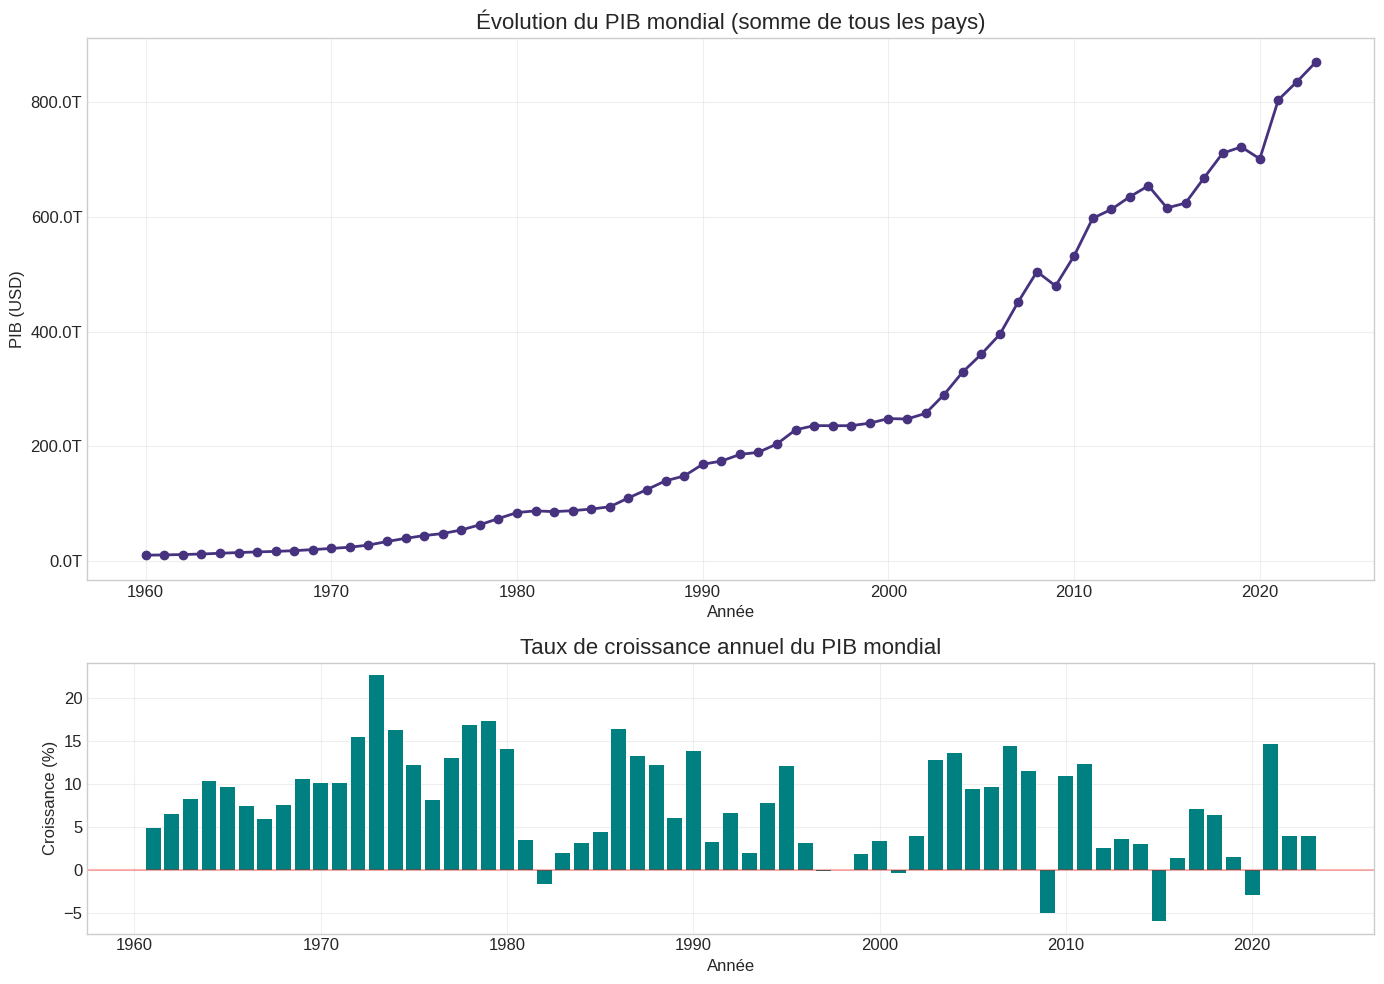

In [ ]:
# Évolution du PIB mondial au fil des années

global_pib_yearly = df.groupby('Year')['Value'].sum().reset_index()
global_pib_yearly['Growth'] = global_pib_yearly['Value'].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(global_pib_yearly['Year'], global_pib_yearly['Value'], marker='o', linewidth=2)
ax1.set_title('Évolution du PIB mondial (somme de tous les pays)', fontsize=16)
ax1.set_xlabel('Année')
ax1.set_ylabel('PIB (USD)')
ax1.yaxis.set_major_formatter(FuncFormatter(trillions))
ax1.grid(True, alpha=0.3)

ax2.bar(global_pib_yearly['Year'], global_pib_yearly['Growth'], color='teal')
ax2.axhline(y=0, color='r', linestyle='-', alpha=0.3)
ax2.set_title('Taux de croissance annuel du PIB mondial', fontsize=16)
ax2.set_xlabel('Année')
ax2.set_ylabel('Croissance (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('global_pib_evolution.png')
plt.show()

<ipython-input-84-be8967402e71>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='CountryName', data=top10_recent, palette='viridis')


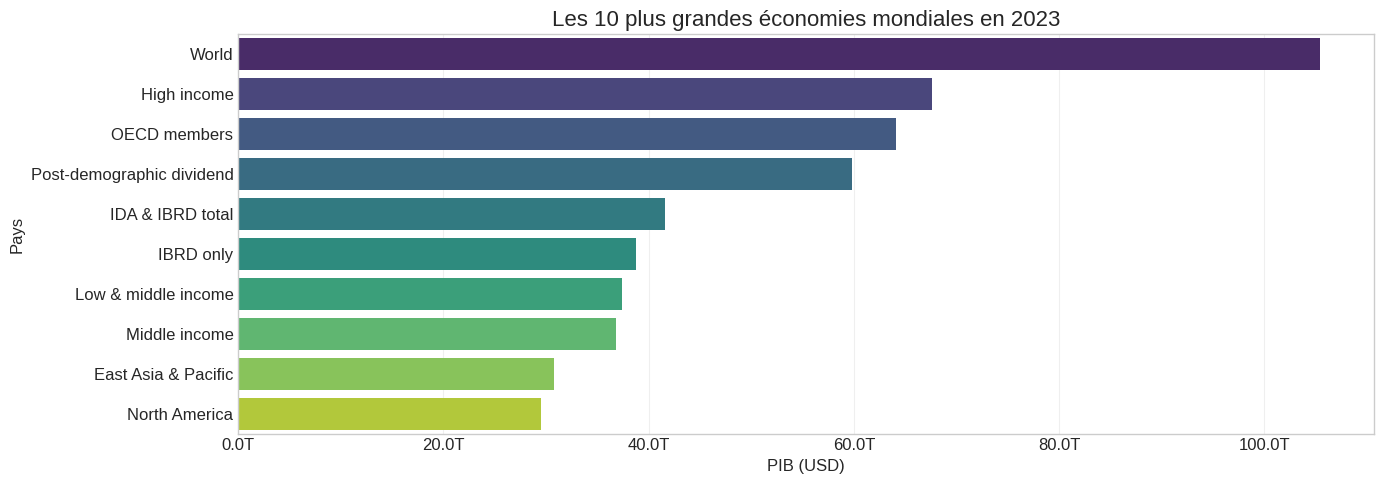

In [ ]:
# 3. Analyser les 10 plus grandes économies (actuellement)
most_recent_year = df['Year'].max() # on recupere la derniere année dans le DF
top10_recent = df[df['Year'] == most_recent_year].sort_values('Value', ascending=False).head(10) # on filtre pour ne garder que les 10 plus gros PIB

plt.figure(figsize=(14, 5))
sns.barplot(x='Value', y='CountryName', data=top10_recent, palette='viridis')
plt.title(f'Les 10 plus grandes économies mondiales en {most_recent_year}', fontsize=16)
plt.xlabel('PIB (USD)')
plt.ylabel('Pays')
plt.gca().xaxis.set_major_formatter(FuncFormatter(trillions))
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top10_economies.png')
plt.show()

<ipython-input-90-554caf590fde>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Decenie', y='GrowthRate', data=croissance_decenie_global, palette='viridis')


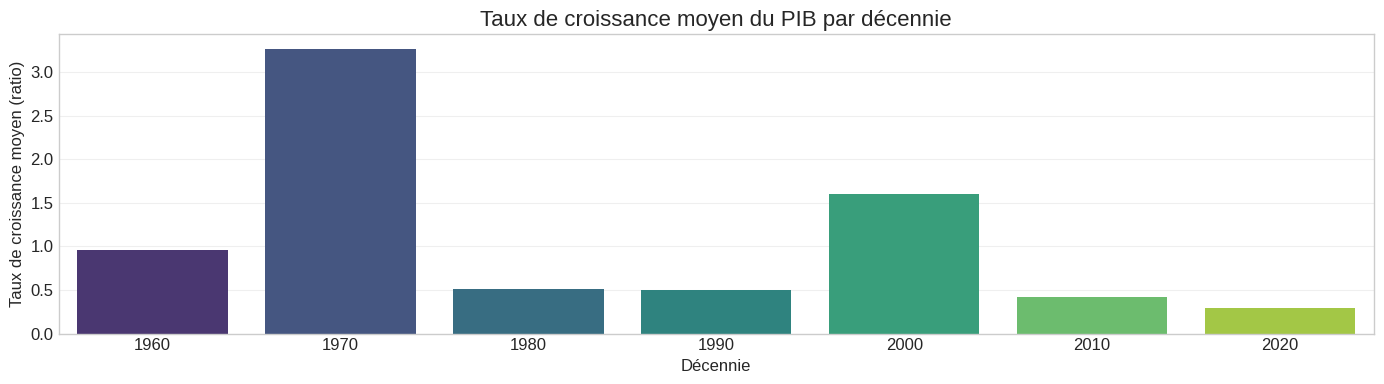

In [ ]:
# Analyse de la croissance moyenne par décennie
df['Decenie'] = (df['Year'] // 10) * 10
croissance_decenie = df.groupby(['CountryName', 'Decenie']).agg({
    'Value': [lambda x: x.iloc[-1] / x.iloc[0] - 1 if len(x) > 1 else np.nan]
}).reset_index()

croissance_decenie.columns = ['CountryName', 'Decenie', 'GrowthRate']
croissance_decenie_global = croissance_decenie.groupby('Decenie')['GrowthRate'].mean().reset_index()

plt.figure(figsize=(14, 4))
sns.barplot(x='Decenie', y='GrowthRate', data=croissance_decenie_global, palette='viridis')
plt.title('Taux de croissance moyen du PIB par décennie', fontsize=16)
plt.xlabel('Décennie')
plt.ylabel('Taux de croissance moyen (ratio)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('croissance_par_decenie.png')
plt.show()

In [ ]:
# Rapport sur les insights majeurs
print("\n--- PRINCIPAUX INSIGHTS DE L'ANALYSE DU PIB MONDIAL ---")
print(f"1. Le PIB mondial est passé de {global_pib_yearly['Value'].iloc[0]/1e12:.2f} trillions USD en {global_pib_yearly['Year'].iloc[0]} à {global_pib_yearly['Value'].iloc[-1]/1e12:.2f} trillions USD en {global_pib_yearly['Year'].iloc[-1]}")

moyenne_croissance = global_pib_yearly['Growth'].mean()
print(f"3. Le taux de croissance annuel moyen du PIB mondial est de {moyenne_croissance:.2f}%")

growth_recent = (global_pib_yearly['Value'].iloc[-1] / global_pib_yearly['Value'].iloc[0]) ** (1 / len(global_pib_yearly)) - 1
print(f"4. Le taux de croissance composé sur l'ensemble de la période est de {growth_recent*100:.2f}%")

# Identification des périodes de récession mondiale
recession_years = global_gdp_yearly[global_gdp_yearly['Growth'] < 0]['Year'].tolist()
if recession_years:
    print(f"5. Années de récession mondiale (croissance négative): {', '.join(map(str, recession_years))}")
else:
    print("5. Aucune année de récession mondiale n'a été identifiée dans les données")




--- PRINCIPAUX INSIGHTS DE L'ANALYSE DU PIB MONDIAL ---
1. Le PIB mondial est passé de 9.94 trillions USD en 1960 à 869.84 trillions USD en 2023
3. Le taux de croissance annuel moyen du PIB mondial est de 7.52%
4. Le taux de croissance composé sur l'ensemble de la période est de 7.24%
5. Années de récession mondiale (croissance négative): 1982, 1997, 2001, 2009, 2015, 2020
